# Phase 1: dataset setup and propagation-tree exploration

This notebook prepares the raw propagation datasets for the first phase of the InfoGuard project. It loads project-wide paths and dataset settings from `config.py`, checks dataset availability, and normalises metadata into a common cascade catalog.

**Primary dataset: WICO** (both WICO Text and WICO Graph). Twitter15 and Twitter16 are loaded for reference and comparison but the core analysis — tree statistics, branching-ratio checks, example selection, and summary charts — targets WICO.

Work carried out here:

1. Load central configuration and create project directories.
2. Load WICO Text (labels) and WICO Graph (propagation structure) and join them.
3. Explore WICO cascades: label distribution, graph anatomy, and structural statistics.
4. Load Twitter15 and Twitter16 separately for reference (kept isolated from WICO analysis).
5. Parse each WICO propagation graph into a directed graph with structural statistics.
6. Save Phase 1 artifacts under the configured evaluation directory.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict, deque
import json
import math
import os
import re
import random
import sys
import importlib.util

import numpy as np
import pandas as pd
import networkx as nx

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


def _load_project_config():
    """Load the central configuration object from the project root.

    Preferred filename is config.py. The fallback supports the uploaded
    config(1).py name used in this chat, so the notebook is runnable here too.
    """
    search_dirs = [Path.cwd(), Path.cwd().parent, Path('/mnt/data')]
    names = ['config.py', 'config(1).py']
    for base in search_dirs:
        for name in names:
            path = base / name
            if path.exists():
                if str(base) not in sys.path:
                    sys.path.insert(0, str(base))
                if name == 'config.py':
                    from config import cfg, ROOT as CONFIG_ROOT
                    return cfg, CONFIG_ROOT, path
                spec = importlib.util.spec_from_file_location('project_config', path)
                module = importlib.util.module_from_spec(spec)
                sys.modules[spec.name] = module
                spec.loader.exec_module(module)
                return module.cfg, module.ROOT, path
    raise FileNotFoundError(
        'Could not find config.py. Place config.py in the project root, '
        'start Jupyter from the project root, or keep config(1).py next to this notebook.'
    )

cfg, CONFIG_ROOT, CONFIG_PATH = _load_project_config()

RANDOM_SEED = cfg.seed
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path(CONFIG_ROOT).resolve()
EVAL_DIR = cfg.paths.evaluation
EVAL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_colwidth', 160)
print(f'Config loaded from: {CONFIG_PATH}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Evaluation directory: {EVAL_DIR}')


Config loaded from: /home/krmsh1n5/Desktop/UFAZ/infoshield/config.py
Project root: /home/krmsh1n5/Desktop/UFAZ/infoshield
Evaluation directory: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation


## 1. Load paths from `config.py`

All dataset and output paths come from the central configuration object. This keeps both notebooks consistent with the rest of the project and avoids hard-coded local paths.


In [2]:
# cfg.paths.make_all() would create a spurious bigcn_best.pt/ directory.
# Create only the directories we actually need.
_DIRS_TO_CREATE = [
    cfg.paths.data_raw,
    cfg.paths.wico_text,
    cfg.paths.wico_graph,
    cfg.paths.twitter15,
    cfg.paths.twitter16,
    cfg.paths.twitter15_trees,
    cfg.paths.twitter16_trees,
    cfg.paths.data_processed,
    cfg.paths.graphs_pt,
    cfg.paths.sbm_matrices,
    cfg.paths.checkpoints,
    cfg.paths.evaluation,
]
for _d in _DIRS_TO_CREATE:
    _d.mkdir(parents=True, exist_ok=True)
print('\u2713 Project directories ready.')

TWITTER15_DIR  = cfg.paths.twitter15
TWITTER16_DIR  = cfg.paths.twitter16
WICO_GRAPH_DIR = cfg.paths.wico_graph
WICO_TEXT_DIR  = cfg.paths.wico_text

CONFIGURED_PATHS = {
    'Twitter15':        TWITTER15_DIR,
    'Twitter16':        TWITTER16_DIR,
    'WICO Text':        WICO_TEXT_DIR,
    'WICO Graph':       WICO_GRAPH_DIR,
    'Processed graphs': cfg.paths.graphs_pt,
    'SBM matrices':     cfg.paths.sbm_matrices,
    'Evaluation':       EVAL_DIR,
}

path_rows = []
for name, path in CONFIGURED_PATHS.items():
    path = Path(path)
    path_rows.append({'name': name, 'path': str(path),
                      'exists': path.exists(), 'is_dir': path.is_dir()})
paths_df = pd.DataFrame(path_rows)
display(paths_df)

missing_inputs = [
    name for name, path in {
        'Twitter15': TWITTER15_DIR, 'Twitter16': TWITTER16_DIR,
        'WICO Text': WICO_TEXT_DIR, 'WICO Graph': WICO_GRAPH_DIR,
    }.items() if not Path(path).exists()
]
if missing_inputs:
    print('Missing dataset directories:', ', '.join(missing_inputs))
    print('Download the missing datasets before running the full notebook.')


✓ Project directories ready.


,name,path,exists,is_dir
0,Twitter15,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15,True,True
1,Twitter16,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter16,True,True
2,WICO Text,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text,True,True
3,WICO Graph,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph,True,True
4,Processed graphs,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/graphs,True,True
5,SBM matrices,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/sbm_matrices,True,True
6,Evaluation,/home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation,True,True


## 2. General parsing helpers

The datasets use different formats. These helpers normalize labels and parse edge files defensively.

In [3]:
def _slug_label(value):
    """Normalize labels for matching while preserving config as source of truth."""
    if value is None or pd.isna(value):
        return ''
    s = str(value).strip().lower().replace('_', ' ').replace('-', ' ')
    return re.sub(r'\s+', ' ', s)


def _labels_from_config(kind):
    """Return raw label aliases whose binary config value maps to kind."""
    aliases = set()
    for label_int, binary in cfg.wico.binary_label_map.items():
        if binary == kind:
            for raw, raw_int in cfg.wico.label_map.items():
                if raw_int == label_int:
                    aliases.add(raw)
            text_file = cfg.wico.text_files.get(label_int)
            if text_file:
                aliases.add(Path(text_file).stem)
    for label_int, binary in cfg.twitter15.binary_label_map.items():
        if binary == kind:
            aliases.update(raw for raw, raw_int in cfg.twitter15.label_map.items() if raw_int == label_int)
    for label_int, binary in cfg.twitter16.binary_label_map.items():
        if binary == kind:
            aliases.update(raw for raw, raw_int in cfg.twitter16.label_map.items() if raw_int == label_int)
    return {_slug_label(x) for x in aliases if x is not None}


TRUE_LABELS = _labels_from_config('true') | {'real', 'credible'}
FALSE_LABELS = _labels_from_config('false') | {'fake', 'misinformation', 'disinformation'}
UNCERTAIN_LABELS = _labels_from_config('uncertain') | {'unknown', 'uncertain'}


def normalize_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {'nan', 'none', 'null'}:
        return None
    if re.fullmatch(r'\d+\.0', s):
        s = s[:-2]
    return s


def normalize_label(label):
    if label is None or pd.isna(label):
        return 'unknown'
    s = _slug_label(label)
    if s in TRUE_LABELS:
        return 'true'
    if s in FALSE_LABELS:
        return 'false'
    if s in UNCERTAIN_LABELS:
        return 'uncertain'
    if 'non' in s and ('rumor' in s or 'conspiracy' in s):
        return 'true'
    if any(k in s for k in ['false', 'fake', 'rumor', 'conspiracy', 'misinfo', 'disinfo']):
        return 'false'
    if any(k in s for k in ['true', 'real', 'credible']):
        return 'true'
    return 'unknown'


def parse_edge_line(line):
    """Parse one edge line from a Twitter15/16 tree file.

    Format from config Twitter15Config/Twitter16Config:
        ['parent_uid', 'parent_tweet_id', 'delay_min']->['child_uid', 'child_tweet_id', 'delay_min']

    Root sentinel comes from cfg.twitter15.root_sentinel or cfg.twitter16.root_sentinel.
    All nodes are USER IDs, which are field 0 of each bracket.
    Returns (parent_uid, child_uid, delay_float) or None.
    """
    raw = line.strip()
    if not raw or '->' not in raw:
        return None
    halves = raw.split('->', 1)
    if len(halves) != 2:
        return None

    def extract_fields(s):
        return re.findall(r"'([^']*?)'", s)

    parent_fields = extract_fields(halves[0])
    child_fields  = extract_fields(halves[1])
    if not parent_fields or not child_fields:
        return None
    parent_uid = normalize_id(parent_fields[0])
    child_uid  = normalize_id(child_fields[0])
    delay = None
    if len(child_fields) >= 3:
        try:
            delay = float(child_fields[2])
        except ValueError:
            pass
    return parent_uid, child_uid, delay


def graph_from_edges(edge_rows, root_sentinel=None):
    """Build a DiGraph from (parent_uid, child_uid, delay) tuples.

    The configured root sentinel line identifies the source user as root_user_id.
    No phantom sentinel node is added, so all node IDs stay in the same user-ID namespace.
    """
    if root_sentinel is None:
        root_sentinel = cfg.twitter15.root_sentinel
    G = nx.DiGraph()
    root_user_id = None

    for parent, child, delay in edge_rows:
        parent = normalize_id(parent)
        child  = normalize_id(child)
        if parent is None or child is None:
            continue
        if parent.upper() == str(root_sentinel).upper():
            if root_user_id is None:
                root_user_id = child
            G.add_node(child)
        else:
            G.add_edge(parent, child)
            if delay is not None:
                G.nodes[child]['delay'] = delay

    return G, root_user_id


def find_roots(G):
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    return roots or list(G.nodes)[:1]


def tree_stats(G, root_id=None):
    """Compute structural statistics for a propagation tree."""
    root_id = normalize_id(root_id)
    if root_id not in G and G.number_of_nodes() > 0:
        root_id = find_roots(G)[0]
    depths = {}
    if root_id in G:
        try:
            depths = nx.single_source_shortest_path_length(G, root_id)
        except Exception:
            depths = {}
    depth_counts = Counter(depths.values())
    cascade_size = G.number_of_nodes()
    max_depth    = max(depth_counts.keys())   if depth_counts else 0
    max_width    = max(depth_counts.values()) if depth_counts else cascade_size

    delays = []
    for _, v in G.nodes(data=True):
        for attr in ('delay', 'time'):
            val = v.get(attr)
            if val is not None:
                try:
                    delays.append(float(val))
                    break
                except (TypeError, ValueError):
                    pass
    temporal_span = max(delays) - min(delays) if len(delays) >= 2 else float('nan')

    # Geometric-mean branching ratio:
    # For each consecutive depth pair (d → d+1) compute |I_{d+1}| / |I_d|.
    # Take the geometric mean across all steps so the depth-1 burst
    # (which can be 1000x) does not dominate the average.
    # This matches the paper's branching ratio concept: expected new
    # infections per currently-infected user per SIR step.
    step_ratios = [
        depth_counts[d + 1] / depth_counts[d]
        for d in sorted(depth_counts.keys())
        if d + 1 in depth_counts and depth_counts[d] > 0
    ]
    if step_ratios:
        log_ratios      = [np.log(r) for r in step_ratios if r > 0]
        branching_ratio = float(np.exp(np.mean(log_ratios))) if log_ratios else 0.0
    else:
        branching_ratio = 0.0

    return {
        'num_nodes':       cascade_size,
        'num_edges':       G.number_of_edges(),
        'cascade_size':    cascade_size,
        'max_depth':       max_depth,
        'max_width':       max_width,
        'branching_ratio': branching_ratio,
        'num_roots':       len(find_roots(G)),
        'is_arborescence': nx.is_arborescence(G) if G.number_of_nodes() > 0 else False,
        'temporal_span':   temporal_span,
    }

print('Helpers defined from central config labels and dataset settings.')


Helpers defined from central config labels and dataset settings.


## 3. Load Twitter15 and Twitter16

These datasets typically include root tweet text, labels, and one propagation-tree file per root tweet.

In [4]:
def load_twitter_labels(dataset_dir, dataset_cfg=None):
    """Read label.txt -> DataFrame[tweet_id, raw_label, label]."""
    dataset_cfg = dataset_cfg or cfg.twitter15
    dataset_dir = Path(dataset_dir)
    label_file  = dataset_dir / dataset_cfg.label_file
    rows = []
    if label_file.exists():
        for line in label_file.read_text(errors='ignore').splitlines():
            line = line.strip()
            if not line or ':' not in line:
                continue
            label, tweet_id = line.split(':', 1)
            rows.append({
                'tweet_id':  normalize_id(tweet_id),
                'raw_label': label.strip(),
                'label':     normalize_label(label.strip()),
            })
    return (pd.DataFrame(rows).drop_duplicates('tweet_id')
            if rows else pd.DataFrame(columns=['tweet_id', 'raw_label', 'label']))


def load_twitter_source_tweets(dataset_dir, dataset_cfg=None):
    """Read source_tweets.txt -> DataFrame[tweet_id, text]."""
    dataset_cfg = dataset_cfg or cfg.twitter15
    dataset_dir = Path(dataset_dir)
    source_file = dataset_dir / dataset_cfg.source_tweets_file
    rows = []
    if source_file.exists():
        for line in source_file.read_text(errors='ignore').splitlines():
            line = line.strip()
            if not line or '\t' not in line:
                continue
            tweet_id, text = line.split('\t', 1)
            rows.append({'tweet_id': normalize_id(tweet_id), 'text': text})
    return (pd.DataFrame(rows).drop_duplicates('tweet_id')
            if rows else pd.DataFrame(columns=['tweet_id', 'text']))


def find_tree_files(trees_subdir, dataset_cfg=None):
    """Return all .txt tree files, skipping label/source files."""
    dataset_cfg = dataset_cfg or cfg.twitter15
    trees_path  = Path(trees_subdir)
    if not trees_path.exists():
        return []
    skip = {dataset_cfg.label_file, dataset_cfg.source_tweets_file}
    return sorted(p for p in trees_path.glob('*.txt') if p.name not in skip)


def load_twitter_tree(path, tweet_id=None, dataset_cfg=None):
    """Parse one tree .txt file into (DiGraph, root_user_id).

    Passes dataset_cfg.root_sentinel to graph_from_edges so that Twitter16
    uses its own config rather than hard-coding cfg.twitter15.
    """
    dataset_cfg = dataset_cfg or cfg.twitter15
    rows = []
    for line in Path(path).read_text(errors='ignore').splitlines():
        parsed = parse_edge_line(line)
        if parsed:
            rows.append(parsed)
    G, root_user_id = graph_from_edges(rows, root_sentinel=dataset_cfg.root_sentinel)
    G.graph['tweet_id'] = normalize_id(tweet_id or Path(path).stem)
    return G, root_user_id


def load_twitter_dataset(name, dataset_dir, dataset_cfg=None):
    """Load labels, source tweets, and all tree graphs for one Twitter dataset.

    trees_subdir is derived from dataset_dir / dataset_cfg.tree_dir so that
    cfg.twitter15.tree_dir / cfg.twitter16.tree_dir are the single source of
    truth for the sub-folder name (currently both = 'tree').
    """
    dataset_cfg  = dataset_cfg or cfg.twitter15
    dataset_dir  = Path(dataset_dir) if dataset_dir else None
    if dataset_dir is None or not dataset_dir.exists():
        print(f'{name}: dataset directory not found.')
        return pd.DataFrame(), {}
    # Derive trees sub-directory from config (cfg.twitterXX.tree_dir = 'tree')
    trees_subdir = dataset_dir / dataset_cfg.tree_dir
    labels     = load_twitter_labels(dataset_dir, dataset_cfg)
    texts      = load_twitter_source_tweets(dataset_dir, dataset_cfg)
    meta       = labels.merge(texts, on='tweet_id', how='outer')
    meta['dataset'] = name
    tree_files = find_tree_files(trees_subdir, dataset_cfg)
    graphs = {}
    for path in tree_files:
        tweet_id = normalize_id(path.stem)
        G, root_user_id = load_twitter_tree(path, tweet_id=tweet_id, dataset_cfg=dataset_cfg)
        n = G.number_of_nodes()
        if dataset_cfg.min_tree_size <= n <= dataset_cfg.max_tree_size:
            graphs[tweet_id] = {
                'graph':    G,
                'path':     str(path),
                'root_id':  root_user_id,  # user ID of source tweeter
                'tweet_id': tweet_id,
            }
    print(f'{name}: {len(meta)} label/text rows, {len(graphs)} trees '
          f'(size filter {dataset_cfg.min_tree_size}\u2013{dataset_cfg.max_tree_size})')
    return meta, graphs


# trees_subdir is now derived inside load_twitter_dataset via dataset_cfg.tree_dir
twitter15_meta, twitter15_graphs = load_twitter_dataset(
    'Twitter15', TWITTER15_DIR, cfg.twitter15
)
twitter16_meta, twitter16_graphs = load_twitter_dataset(
    'Twitter16', TWITTER16_DIR, cfg.twitter16
)

display(pd.concat([twitter15_meta.head(5), twitter16_meta.head(5)], ignore_index=True))


Twitter15: 1490 label/text rows, 1463 trees (size filter 3–2000)
Twitter16: 818 label/text rows, 800 trees (size filter 3–2000)


,tweet_id,raw_label,label,text,dataset
0,265953285247209472,false,false,deep-fried left wings demo-crab cakes barack-amole & chips malia quesadillas hawaiian pizza sloppy joe bidens obamacare-rot cake,Twitter15
1,273182568298450945,false,false,42 million dead in bloodiest black friday weekend on record URL,Twitter15
2,273278761909239808,false,false,42 million dead in bloodiest black friday weekend on record URL,Twitter15
3,295152287901417472,true,true,#prayforchristopher 5k run .. well we are walking lol @savannahn_2012 @lemongella URL,Twitter15
4,295944137948151809,false,false,a photo of black nurses saving the life of a kkk member. URL,Twitter15
5,498430783699554305,true,true,witness: police allegedly stopped mike brown after yelling at him to walk on sidewalk. #ferguson URL,Twitter16
6,500378223977721856,true,true,"oh. so now the #ferguson police chief says the cop didn't know about the robbery when he stopped #mikebrown. the kid was ""jaywalking""? bs!",Twitter16
7,524922729485848576,true,true,only photo i will tweet. cpr being performed on the soldier now. i heard four shots. #ottawa URL,Twitter16
8,524923462398513152,true,true,shots fired on parliament hill after a man walked up with a gun. i'm locked in a security office on parliament hill,Twitter16
9,524923676484177920,true,true,breaking - shooting on parliament hill. rcmp have weapons drawn #cdnpoli URL,Twitter16


## 4. Load WICO Text separately

WICO Text is used for labels and textual metadata. It may not contain propagation edges.

In [5]:
def load_wico_text_dataset(wico_text_dir):
    """Load WICO Text: one .txt file per class, each line is a bare tweet ID."""
    if wico_text_dir is None or not Path(wico_text_dir).exists():
        print('WICO Text directory not found.')
        return pd.DataFrame(columns=['content_id','tweet_id','raw_label','label','text_path'])
    wico_text_dir = Path(wico_text_dir)
    # Derive labels from config — single source of truth:
    #   cfg.wico.label_map        = {'5g-conspiracy':0, 'conspiracy':1, 'non-conspiracy':2}
    #   cfg.wico.binary_label_map = {0:'false', 1:'false', 2:'true'}
    int_to_raw = {v: k for k, v in cfg.wico.label_map.items()}
    rows = []
    for label_int, fname in cfg.wico.text_files.items():
        path = wico_text_dir / fname
        if not path.exists():
            print(f'  Missing WICO Text file: {path}')
            continue
        raw_label  = int_to_raw.get(label_int, str(label_int))  # e.g. '5g-conspiracy'
        norm_label = cfg.wico.binary_label_map.get(label_int, 'unknown')  # 'false'/'true'
        for line in path.read_text(errors='ignore').splitlines():
            tweet_id = normalize_id(line.strip())
            if tweet_id is None:
                continue
            rows.append({
                'content_id': tweet_id,
                'tweet_id':   tweet_id,
                'raw_label':  raw_label,
                'label':      norm_label,
                'text_path':  str(path),
            })
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.drop_duplicates('content_id')
    print(f'WICO Text: {len(out)} tweet IDs across {len(cfg.wico.text_files)} files')
    return out

wico_text = load_wico_text_dataset(WICO_TEXT_DIR)
display(wico_text.head())
display(wico_text['label'].value_counts(dropna=False).rename('count').to_frame()
        if not wico_text.empty else wico_text)


WICO Text: 9688 tweet IDs across 3 files


,content_id,tweet_id,raw_label,label,text_path
0,1037704685652561926,1037704685652561926,5g-conspiracy,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
1,1200224860561199104,1200224860561199104,5g-conspiracy,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
2,1221197064740143104,1221197064740143104,5g-conspiracy,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
3,1221428849881370626,1221428849881370626,5g-conspiracy,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
4,1222024051830509568,1222024051830509568,5g-conspiracy,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt


,count
label,
true,6618
false,3070


## 5. Load WICO Graph separately

WICO Graph provides propagation structure. The parser below groups graph files by content ID when files are one cascade each. If the graph files contain columns, it tries to infer source, target, and cascade/content ID columns.

In [6]:
def _wico_find_root(G, nodes_df):
    """Choose the best root node for a WICO propagation graph.

    WICO edges.txt is a follower/connection graph around a tweet.  The
    folder name is the tweet ID (different namespace from user IDs in
    edges.txt/nodes.csv) so we must NOT add it as a graph node.

    Priority:
      1. Node with the highest 'followers' count in nodes.csv.
      2. Node with the highest in-degree in the graph.
      3. First node in nodes.csv that appears in the graph.
    """
    if not nodes_df.empty and 'id' in nodes_df.columns:
        if 'followers' in nodes_df.columns:
            cands = nodes_df[nodes_df['id'].map(normalize_id).isin(G.nodes)].copy()
            if not cands.empty:
                try:
                    cands['followers'] = pd.to_numeric(cands['followers'], errors='coerce')
                    best = cands.loc[cands['followers'].idxmax(), 'id']
                    bid  = normalize_id(best)
                    if bid in G:
                        return bid
                except Exception:
                    pass
        for _, nr in nodes_df.iterrows():
            nid = normalize_id(nr.get('id'))
            if nid and nid in G:
                return nid
    if G.number_of_nodes() > 0:
        return max(G.nodes, key=lambda n: G.in_degree(n))
    return None


def load_wico_graph_cascade(tweet_dir):
    """Load one cascade from a per-tweet WICO Graph directory.

    FIX: the folder name (tweet ID) is NOT added as a graph node because
    it lives in a different namespace from the user IDs in edges.txt and
    nodes.csv.  _wico_find_root() selects the most-followed user as root.

    Returns (G, root_user_id).
    """
    tweet_dir  = Path(tweet_dir)
    edges_path = tweet_dir / cfg.wico.graph_edges_file
    G = nx.DiGraph()
    if edges_path.exists():
        for line in edges_path.read_text(errors='ignore').splitlines():
            parts = line.strip().split()
            if len(parts) == 2:
                src, dst = normalize_id(parts[0]), normalize_id(parts[1])
                if src and dst:
                    G.add_edge(src, dst)

    nodes_path = tweet_dir / cfg.wico.graph_nodes_file
    nodes_df   = pd.DataFrame()
    if nodes_path.exists():
        nodes_df = pd.read_csv(nodes_path, dtype=str)
        nodes_df.columns = [c.strip().lower() for c in nodes_df.columns]
        for col in list(cfg.wico.graph_nodes_columns):
            if col not in nodes_df.columns:
                nodes_df[col] = None
        # Load features listed in cfg.wico.graph_nodes_columns, skipping 'id'
        _feat_cols = [c for c in cfg.wico.graph_nodes_columns if c != 'id']
        for _, row in nodes_df.iterrows():
            nid = normalize_id(row['id'])
            if nid:
                G.add_node(nid)
                for feat in _feat_cols:
                    try:
                        G.nodes[nid][feat] = int(float(row[feat]))
                    except (ValueError, KeyError, TypeError):
                        pass

    root_user_id        = _wico_find_root(G, nodes_df)
    G.graph['tweet_id'] = normalize_id(tweet_dir.name)
    return G, root_user_id


def load_wico_graph_dataset(wico_graph_dir):
    """Walk cfg.wico.graph_dirs and load every per-tweet cascade."""
    if wico_graph_dir is None or not Path(wico_graph_dir).exists():
        print('WICO Graph directory not found.')
        return {}, pd.DataFrame(columns=['content_id', 'graph_path', 'label_int'])
    wico_graph_dir = Path(wico_graph_dir)
    graphs = {}
    manifest_rows = []
    for label_int, folder_name in cfg.wico.graph_dirs.items():
        class_dir = wico_graph_dir / folder_name
        if not class_dir.exists():
            print(f'  Missing WICO Graph folder: {class_dir}')
            continue
        tweet_dirs = sorted(p for p in class_dir.iterdir() if p.is_dir())
        for tweet_dir in tweet_dirs:
            G, root_user_id = load_wico_graph_cascade(tweet_dir)
            if G.number_of_nodes() == 0:
                continue
            content_id = normalize_id(tweet_dir.name)
            graphs[content_id] = {
                'graph':    G,
                'path':     str(tweet_dir),
                'root_id':  root_user_id,  # user ID, NOT folder name
                'tweet_id': content_id,
            }
            manifest_rows.append({
                'content_id': content_id,
                'graph_path': str(tweet_dir),
                'label_int':  label_int,
            })
    print(f'WICO Graph: {len(graphs)} cascades from {len(cfg.wico.graph_dirs)} class folders')
    manifest = (pd.DataFrame(manifest_rows).drop_duplicates('content_id')
                if manifest_rows else pd.DataFrame(
                    columns=['content_id', 'graph_path', 'label_int']))
    return graphs, manifest

wico_graphs, wico_graph_manifest = load_wico_graph_dataset(WICO_GRAPH_DIR)
display(wico_graph_manifest.head())


WICO Graph: 2502 cascades from 3 class folders


,content_id,graph_path,label_int
0,1,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/1,0
1,10,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/10,0
2,100,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/100,0
3,101,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/101,0
4,102,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/102,0


## 6. Join WICO Text and WICO Graph

This is the important rewrite for the two-dataset case. WICO Text and WICO Graph are separate inputs, so the notebook creates a joined metadata table. Cascades without matching text labels are kept with `unknown` labels instead of being discarded.

In [7]:
def build_wico_joined_metadata(wico_text, wico_graph_manifest):
    """Assign labels from the graph subfolder structure (not tweet-ID join).

    WICO Graph folder names are sequential integers (1, 2, 3 ...).
    WICO Text stores real tweet IDs.  The two never match, so we label
    directly from label_int set by load_wico_graph_dataset.

    Label strings are derived from config (cfg.wico.label_map / binary_label_map)
    and never hardcoded, so changes to config automatically propagate here.
    """
    # Derive from config — do not hardcode label strings here:
    #   cfg.wico.binary_label_map = {0:'false', 1:'false', 2:'true'}
    #   cfg.wico.label_map        = {'5g-conspiracy':0, 'conspiracy':1, 'non-conspiracy':2}
    WICO_INT_TO_LABEL = cfg.wico.binary_label_map
    WICO_INT_TO_RAW   = {v: k for k, v in cfg.wico.label_map.items()}  # {0:'5g-conspiracy', 1:'conspiracy', 2:'non-conspiracy'}

    if wico_graph_manifest.empty:
        return pd.DataFrame(columns=[
            'dataset', 'tweet_id', 'content_id', 'label',
            'raw_label', 'graph_path', 'has_graph', 'has_text'
        ])

    joined = wico_graph_manifest.copy()
    joined['content_id'] = joined['content_id'].map(normalize_id)
    joined['tweet_id']   = joined['content_id']
    joined['label']      = joined['label_int'].map(WICO_INT_TO_LABEL).fillna('unknown')
    joined['raw_label']  = joined['label_int'].map(WICO_INT_TO_RAW)
    joined['dataset']    = 'WICO'
    joined['has_graph']  = True
    joined['has_text']   = False

    return joined[[
        'dataset', 'tweet_id', 'content_id', 'label',
        'raw_label', 'graph_path', 'has_graph', 'has_text'
    ]]

wico_meta = build_wico_joined_metadata(wico_text, wico_graph_manifest)
print('Joined WICO rows:', len(wico_meta))
display(wico_meta['label'].value_counts(dropna=False).rename('count').to_frame())
display(wico_meta.head())


Joined WICO rows: 2502


,count
label,
true,1905
false,597


,dataset,tweet_id,content_id,label,raw_label,graph_path,has_graph,has_text
0,WICO,1,1,false,5g-conspiracy,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/1,True,False
1,WICO,10,10,false,5g-conspiracy,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/10,True,False
2,WICO,100,100,false,5g-conspiracy,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/100,True,False
3,WICO,101,101,false,5g-conspiracy,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/101,True,False
4,WICO,102,102,false,5g-conspiracy,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/102,True,False


## 7. Single-tree anatomy — WICO Graph

Before computing bulk statistics, walk through one specific WICO cascade in detail.
This confirms the WICO graph parser is correct and makes the graph structure concrete.
Each measure computed here maps directly to a quantity used in the paper:
- `cascade_size` → R∞ (final infected set size the LP tries to minimise)
- `max_depth` → how many SIR iterations the cascade ran
- `branching_ratio` → the α parameter the LP preserves for true content

**Note:** Twitter15/16 anatomy is available in Section 3b-Twitter below.

In [8]:
# Pick the largest false-content cascade from WICO for the anatomy walk.
# Falls back to Twitter15 only if WICO data is absent.

anatomy_id  = None
anatomy_src = None   # 'WICO' or 'Twitter15'

if wico_graphs:
    # Prefer a false/conspiracy cascade
    wico_false_ids = []
    for cid, payload in wico_graphs.items():
        row = wico_meta[wico_meta['content_id'].eq(cid)] if not wico_meta.empty else pd.DataFrame()
        lbl = row['label'].values[0] if not row.empty else 'unknown'
        if lbl == 'false':
            wico_false_ids.append((cid, payload['graph'].number_of_nodes()))
    if wico_false_ids:
        anatomy_id  = max(wico_false_ids, key=lambda x: x[1])[0]
        anatomy_src = 'WICO'
    elif wico_graphs:
        anatomy_id  = next(iter(wico_graphs))
        anatomy_src = 'WICO'

if anatomy_id is None and twitter15_graphs:
    print('No WICO graphs available. Falling back to Twitter15.')
    anatomy_id  = next(iter(twitter15_graphs))
    anatomy_src = 'Twitter15'

if anatomy_id and anatomy_src == 'WICO':
    payload  = wico_graphs[anatomy_id]
    G        = payload['graph']
    root_id  = payload.get('root_id')
    row_meta = wico_meta[wico_meta['content_id'].eq(anatomy_id)] if not wico_meta.empty else pd.DataFrame()
    label    = row_meta['label'].values[0] if not row_meta.empty else 'unknown'

    bfs_root   = (root_id if (root_id and root_id in G)
                  else (max(G.nodes, key=lambda n: G.in_degree(n)) if G.number_of_nodes() > 0 else None))
    depths     = nx.single_source_shortest_path_length(G, bfs_root) if bfs_root else {}
    depth_dist = Counter(depths.values())
    leaves     = [n for n in G.nodes if G.out_degree(n) == 0]
    non_leaf_d = [d for _, d in G.out_degree() if d > 0]

    print('=== WICO SINGLE-GRAPH ANATOMY ===')
    print(f'Content ID (folder name): {anatomy_id}')
    print(f'Label                   : {label}')
    print(f'Root user ID            : {root_id}')
    print()
    print(f'Nodes (users who participated): {G.number_of_nodes()}')
    print(f'Edges (follower/retweet links) : {G.number_of_edges()}')
    print(f'Is valid arborescence         : {nx.is_arborescence(G)}')
    print()
    print(f'Root node (most-followed user): {bfs_root}')
    print(f'Leaf nodes (no further spread): {len(leaves)}')
    print(f'Max cascade depth             : {max(depth_dist) if depth_dist else 0}')
    print(f'Nodes per depth level         : {dict(sorted(depth_dist.items()))}')
    avg_b = f'{np.mean(non_leaf_d):.3f}' if non_leaf_d else 'N/A'
    print(f'Avg branching factor          : {avg_b}')
    print()
    print('--- What each measure means for the paper ---')
    print('Nodes            = |It| across all SIR iterations = R∞ (final cascade size)')
    print('Edges            = individual p_ij content transfers (eq. 4 of the paper)')
    print('Max depth        = number of SIR cascade steps before propagation stopped')
    print('Branching factor = empirical branching ratio ≈ α the LP must preserve')
    print('                   Paper tests α ∈ {1.5, 2.0, 3.0} — our WICO data gives the range')
elif anatomy_id and anatomy_src == 'Twitter15':
    payload   = twitter15_graphs[anatomy_id]
    G         = payload['graph']
    root_id   = payload.get('root_id')
    row       = (twitter15_meta[twitter15_meta['tweet_id'].eq(anatomy_id)]
                 if not twitter15_meta.empty else pd.DataFrame())
    root_text = (row['text'].values[0]
                 if not row.empty and 'text' in row.columns else '[text not found]')
    bfs_root   = (root_id if (root_id and root_id in G)
                  else (find_roots(G)[0] if G.number_of_nodes() > 0 else None))
    depths     = nx.single_source_shortest_path_length(G, bfs_root) if bfs_root else {}
    depth_dist = Counter(depths.values())
    leaves     = [n for n in G.nodes if G.out_degree(n) == 0]
    non_leaf_d = [d for _, d in G.out_degree() if d > 0]

    print('=== TWITTER15 SINGLE-TREE ANATOMY (fallback — no WICO data) ===')
    print(f'Tweet ID : {anatomy_id}')
    print(f'Root text: "{root_text[:120]}"')
    print(f'Nodes: {G.number_of_nodes()}  Edges: {G.number_of_edges()}')
    print(f'Max depth: {max(depth_dist) if depth_dist else 0}')
    avg_b = f'{np.mean(non_leaf_d):.3f}' if non_leaf_d else 'N/A'
    print(f'Avg branching factor: {avg_b}')
else:
    print('No graphs loaded — check that WICO Graph and Twitter15 data paths are correct.')


=== WICO SINGLE-GRAPH ANATOMY ===
Content ID (folder name): 350
Label                   : false
Root user ID            : 89914996

Nodes (users who participated): 100
Edges (follower/retweet links) : 60
Is valid arborescence         : False

Root node (most-followed user): 89914996
Leaf nodes (no further spread): 58
Max cascade depth             : 2
Nodes per depth level         : {0: 1, 1: 10, 2: 2}
Avg branching factor          : 1.429

--- What each measure means for the paper ---
Nodes            = |It| across all SIR iterations = R∞ (final cascade size)
Edges            = individual p_ij content transfers (eq. 4 of the paper)
Max depth        = number of SIR cascade steps before propagation stopped
Branching factor = empirical branching ratio ≈ α the LP must preserve
                   Paper tests α ∈ {1.5, 2.0, 3.0} — our WICO data gives the range


## 7b. Twitter15/16 single-tree anatomy (reference only)

This section performs the same anatomy walk on a Twitter15 tree.
It is kept **separate** from the WICO analysis and is for cross-dataset reference only.

In [9]:
# ── Twitter15 anatomy: reference only, does NOT feed into WICO analysis ──
if twitter15_graphs:
    labels_lookup = (twitter15_meta.set_index('tweet_id')['label'].to_dict()
                     if not twitter15_meta.empty else {})
    false_ids_t15 = [
        tid for tid in twitter15_graphs
        if normalize_label(labels_lookup.get(tid, 'unknown')) == 'false'
    ]
    t15_id = (max(false_ids_t15, key=lambda t: twitter15_graphs[t]['graph'].number_of_nodes())
              if false_ids_t15 else next(iter(twitter15_graphs)))
    t15_payload   = twitter15_graphs[t15_id]
    t15_G         = t15_payload['graph']
    t15_root_id   = t15_payload.get('root_id')
    t15_row       = (twitter15_meta[twitter15_meta['tweet_id'].eq(t15_id)]
                     if not twitter15_meta.empty else pd.DataFrame())
    t15_root_text = (t15_row['text'].values[0]
                     if not t15_row.empty and 'text' in t15_row.columns else '[text not found]')
    t15_bfs_root  = (t15_root_id if (t15_root_id and t15_root_id in t15_G)
                     else (find_roots(t15_G)[0] if t15_G.number_of_nodes() > 0 else None))
    t15_depths    = nx.single_source_shortest_path_length(t15_G, t15_bfs_root) if t15_bfs_root else {}
    t15_depth_dist = Counter(t15_depths.values())
    t15_leaves     = [n for n in t15_G.nodes if t15_G.out_degree(n) == 0]
    t15_non_leaf_d = [d for _, d in t15_G.out_degree() if d > 0]

    print('=== TWITTER15 SINGLE-TREE ANATOMY (reference) ===')
    print(f'Tweet ID : {t15_id}')
    print(f'Root user: {t15_root_id}')
    print(f'Text     : "{t15_root_text[:120]}"')
    print()
    print(f'Nodes: {t15_G.number_of_nodes()}  Edges: {t15_G.number_of_edges()}')
    print(f'Is valid arborescence: {nx.is_arborescence(t15_G)}')
    print(f'Max depth            : {max(t15_depth_dist) if t15_depth_dist else 0}')
    print(f'Nodes per depth      : {dict(sorted(t15_depth_dist.items()))}')
    avg_b = f'{np.mean(t15_non_leaf_d):.3f}' if t15_non_leaf_d else 'N/A'
    print(f'Avg branching factor : {avg_b}')
    print()
    print('Twitter15 anatomy is for reference. It does NOT feed into the WICO analysis below.')
else:
    print('Twitter15 not loaded — anatomy skipped.')


=== TWITTER15 SINGLE-TREE ANATOMY (reference) ===
Tweet ID : 295944137948151809
Root user: 1109500842
Text     : "a photo of black nurses saving the life of a kkk member. URL"

Nodes: 1991  Edges: 2000
Is valid arborescence: False
Max depth            : 5
Nodes per depth      : {0: 1, 1: 1514, 2: 353, 3: 93, 4: 24, 5: 6}
Avg branching factor : 5.900

Twitter15 anatomy is for reference. It does NOT feed into the WICO analysis below.


## 8. Build a unified propagation-tree catalog

The catalog records every cascade that has a graph. It also keeps labels from the appropriate metadata source.

In [10]:
all_graphs     = {}
all_meta_parts = []

for dataset_name, meta, graphs in [
    ('Twitter15', twitter15_meta, twitter15_graphs),
    ('Twitter16', twitter16_meta, twitter16_graphs),
]:
    if graphs:
        for tweet_id, payload in graphs.items():
            all_graphs[(dataset_name, tweet_id)] = payload
        if not meta.empty:
            tmp = meta.copy()
            tmp['content_id'] = tmp['tweet_id']
            tmp['has_graph']  = tmp['tweet_id'].isin(graphs.keys())
            tmp['has_text']   = (tmp['text'].fillna('').astype(str).str.len() > 0
                                 if 'text' in tmp.columns else False)
            if 'raw_label' not in tmp.columns:
                tmp['raw_label'] = None
            if 'label' not in tmp.columns:
                tmp['label'] = 'unknown'
            tmp['graph_path'] = tmp['tweet_id'].map(
                lambda x: graphs.get(normalize_id(x), {}).get('path'))
            text_col = tmp['text'] if 'text' in tmp.columns else pd.Series('', index=tmp.index)
            tmp['text'] = text_col.fillna('')
            all_meta_parts.append(
                tmp[['dataset','tweet_id','content_id','label','raw_label',
                     'text','graph_path','has_graph','has_text']])

if wico_graphs:
    for cid, payload in wico_graphs.items():
        all_graphs[('WICO', cid)] = payload
if not wico_meta.empty:
    wico_meta_aligned = wico_meta.copy()
    wico_meta_aligned['text'] = ''
    all_meta_parts.append(
        wico_meta_aligned[['dataset','tweet_id','content_id','label','raw_label',
                            'text','graph_path','has_graph','has_text']])

all_meta = (pd.concat(all_meta_parts, ignore_index=True) if all_meta_parts
            else pd.DataFrame(columns=[
                'dataset','tweet_id','content_id','label','raw_label',
                'text','graph_path','has_graph','has_text']))
all_meta['tweet_id']   = all_meta['tweet_id'].map(normalize_id)
all_meta['content_id'] = all_meta['content_id'].map(normalize_id)
all_meta['label']      = all_meta['label'].fillna('unknown').map(normalize_label)

print('Total graphs:', len(all_graphs))
print('Total metadata rows:', len(all_meta))
display(all_meta.groupby(['dataset','label']).size().rename('count').reset_index())


Total graphs: 4765
Total metadata rows: 4810


,dataset,label,count
0,Twitter15,false,370
1,Twitter15,true,746
2,Twitter15,uncertain,374
3,Twitter16,false,205
4,Twitter16,true,412
5,Twitter16,uncertain,201
6,WICO,false,597
7,WICO,true,1905


## 9. Compute propagation-tree statistics

These features are the Phase 1 bridge from raw files to paper-inspired modeling:

- `cascade_size` approximates final reach.
- `max_depth` captures how many reshare generations exist.
- `max_width` captures burstiness at a depth.
- `branching_ratio` approximates average edge expansion.
- `is_arborescence` checks whether the cascade is a clean tree.

In [11]:
summary_rows = []
meta_lookup  = (all_meta.set_index(['dataset','content_id']).to_dict('index')
                if not all_meta.empty else {})
for (dataset, cid), payload in all_graphs.items():
    G       = payload['graph']
    root_id = payload.get('root_id')   # user ID of source tweeter (fixed)
    stats   = tree_stats(G, root_id=root_id)
    meta    = meta_lookup.get((dataset, cid), {})
    summary_rows.append({
        'dataset':    dataset,
        'tweet_id':   cid,
        'content_id': cid,
        'root_user':  root_id,
        'label':      normalize_label(meta.get('label', 'unknown')),
        'raw_label':  meta.get('raw_label'),
        'graph_path': payload.get('path'),
        'text':       meta.get('text', ''),
        **stats,
    })

summary_columns = [
    'dataset','tweet_id','content_id','root_user','label','raw_label',
    'graph_path','text','num_nodes','num_edges','cascade_size','max_depth',
    'max_width','branching_ratio','num_roots','is_arborescence','temporal_span'
]
tree_summary = pd.DataFrame(summary_rows, columns=summary_columns)
if not tree_summary.empty:
    tree_summary = tree_summary.sort_values(
        ['dataset','label','cascade_size'], ascending=[True, True, False])

summary_path = EVAL_DIR / 'propagation_tree_summary.csv'
tree_summary.to_csv(summary_path, index=False)
print('Saved:', summary_path)
display(tree_summary.head(20))

display(tree_summary.groupby(['dataset','label'])[
    ['cascade_size','max_depth','max_width','branching_ratio']
].describe().round(2) if not tree_summary.empty else tree_summary)


Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/propagation_tree_summary.csv


,dataset,tweet_id,content_id,root_user,label,raw_label,graph_path,text,num_nodes,num_edges,cascade_size,max_depth,max_width,branching_ratio,num_roots,is_arborescence,temporal_span
4,Twitter15,295944137948151809,295944137948151809,1109500842,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/295944137948151809.txt,a photo of black nurses saving the life of a kkk member. URL,1991,2000,1991,5,1514,1.430969,1,False,1440122.62
735,Twitter15,537377960471166976,537377960471166976,29417304,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/537377960471166976.txt,"y'all, i just read that abc paid darren wilson $500k for the interview. destroying black life remains a lucrative american career. #ferguson",1863,1907,1863,5,1227,1.148698,1,False,24541.17
900,Twitter15,560442390805090307,560442390805090307,14319981,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/560442390805090307.txt,drift into a peaceful slumber w/@thejeffbridges' new #sleepingtapes album. listen now at URL #om URL,1748,1781,1748,3,1583,1.912931,1,False,288113.27
169,Twitter15,489794593580650497,489794593580650497,271413771,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/489794593580650497.txt,breaking: malaysia airlines passenger 'shot down' near russian border in ukraine URL URL,1686,1692,1686,10,756,1.071773,1,False,6978.11
280,Twitter15,504433135036407808,504433135036407808,328810158,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/504433135036407808.txt,gonna be unreal when las vegas goes undefeated at home every year........ #nhl #expansion,1609,1619,1609,3,1498,1.817121,1,False,1031961.87
683,Twitter15,532281981795848192,532281981795848192,138749160,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/532281981795848192.txt,manager bans teen slang from work including 'chill'. adds stop accusing people of having ebola URL URL,1596,1609,1596,8,798,1.222845,1,False,400340.75
37,Twitter15,376982539132366848,376982539132366848,149760844,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/376982539132366848.txt,j.k. rowling is working on an 8th harry potter book.,1527,1546,1527,3,1437,1.259921,1,False,263645.52
454,Twitter15,521727831307722753,521727831307722753,221452291,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/521727831307722753.txt,someone spray painted a penis on a $2.4 mill bugatti URL,1435,1443,1435,4,1119,1.732051,1,False,535534.79
168,Twitter15,489794369487380480,489794369487380480,227423066,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/489794369487380480.txt,breaking: malaysian airlines passenger 'shot down' near russian border in ukraine URL URL,1388,1389,1388,6,1145,1.000000,1,False,4299.15
657,Twitter15,531607884220485632,531607884220485632,14926475,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/531607884220485632.txt,apec photo of the day. rt @marc_leibowitz: photo of vladimir putin's motorcade. posted without comment. URL,1374,1407,1374,9,442,1.080060,1,False,630015.13


cascade_size                                               \
                           count    mean     std   min     25%    50%     75%   
dataset   label                                                                 
Twitter15 false            365.0  324.92  321.29  97.0  143.00  204.0  355.00   
          true             728.0  435.26  329.45  88.0  194.25  351.0  553.00   
          uncertain        370.0  261.23  256.59  56.0  127.00  165.5  275.00   
Twitter16 false            198.0  293.63  266.05  74.0  136.00  211.0  331.75   
          true             405.0  468.37  355.74  90.0  213.00  337.0  659.00   
          uncertain        197.0  280.39  303.12  94.0  130.00  166.0  292.00   
WICO      false            597.0   63.21   34.10   3.0   27.00   84.0   92.00   
          true            1905.0   62.68   34.91   3.0   24.00   85.0   92.00   

                            max_depth        ... max_width          \
                        max     count  mean  ...       75%     max   
dataset   label                              ...                     
Twitter15 false      1991.0     365.0  3.58  ...    271.00  1583.0   
          true       1987.0     728.0  3.59  ...    447.25  1771.0   
          uncertain  1971.0     370.0  3.64  ...    216.00  1268.0   
Twitter16 false      1596.0     198.0  3.74  ...    267.00  1199.0   
          true       1949.0     405.0  3.85  ...    501.00  1465.0   
          uncertain  1971.0     197.0  3.42  ...    225.00  1268.0   
WICO      false       100.0     597.0  1.66  ...      9.00    75.0   
          true        101.0    1905.0  1.57  ...      7.00    93.0   

                    branching_ratio                                             
                              count  mean    std  min  25%   50%   75%     max  
dataset   label                                                                 
Twitter15 false               365.0  2.72  13.28  1.0  1.0  1.26  2.00  225.00  
          true                728.0  3.05  19.32  1.0  1.0  1.26  1.91  485.00  
          uncertain           370.0  1.73   1.24  1.0  1.0  1.26  1.82    9.33  
Twitter16 false               198.0  1.63   0.96  1.0  1.0  1.26  1.73    6.93  
          true                405.0  2.16   8.63  1.0  1.0  1.26  1.71  173.00  
          uncertain           197.0  1.86   1.50  1.0  1.0  1.26  1.82    9.33  
WICO      false               597.0  1.22   3.65  0.0  0.0  1.00  1.26   70.00  
          true               1905.0  0.98   1.65  0.0  0.0  1.00  1.26   33.00  

[8 rows x 32 columns]

## 9b. Branching ratio and the paper's α parameter

The LP optimizer (Algorithm 2) preserves true content by requiring its
branching ratio to stay above α after dropouts are applied. This cell
checks what fraction of our true-content trees already exceed α = 1.5
without any alteration, and shows how the distributions differ between
true and false content — the empirical foundation the dropout method relies on.


=== BRANCHING RATIO vs PAPER α PARAMETER ===
LP optimizer default α = 1.5 (cfg.lp.alpha)
Fraction of trees with branching_ratio ≥ α (unaltered network):

PRIMARY DATASET: WICO
  [false] 5g-conspiracy  (n=412)
    α=1.0   60.4% of cascades exceed threshold
    α=1.5   17.0% of cascades exceed threshold
    α=2.0   12.1% of cascades exceed threshold
    α=3.0    5.3% of cascades exceed threshold
  [false] conspiracy  (n=185)
    α=1.0   55.7% of cascades exceed threshold
    α=1.5   16.8% of cascades exceed threshold
    α=2.0   12.4% of cascades exceed threshold
    α=3.0    5.4% of cascades exceed threshold
  [true] non-conspiracy  (n=1905)
    α=1.0   58.0% of cascades exceed threshold
    α=1.5   16.9% of cascades exceed threshold
    α=2.0   11.6% of cascades exceed threshold
    α=3.0    4.5% of cascades exceed threshold

REFERENCE DATASETS (Twitter15/16) — separate from WICO analysis:
  Twitter15
    α=1.0  true:  94.5%  |  false:  93.7%
    α=1.5  true:  37.1%  |  false:  35.1%
 

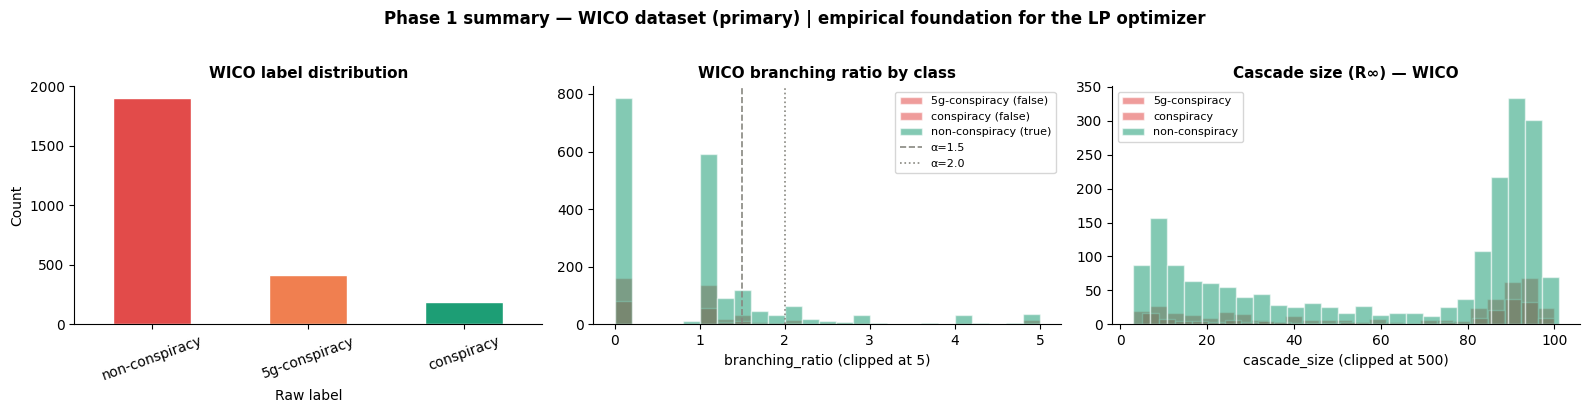

In [12]:
if not tree_summary.empty:
    # cfg.lp.alpha is the LP optimizer's default safety parameter (1.5).
    # Test a range bracketing it to show feasibility at different thresholds.
    ALPHA_VALUES = sorted({1.0, cfg.lp.alpha, 2.0, 3.0})

    print('=== BRANCHING RATIO vs PAPER α PARAMETER ===')
    print(f'LP optimizer default α = {cfg.lp.alpha} (cfg.lp.alpha)')
    print('Fraction of trees with branching_ratio ≥ α (unaltered network):')
    print()

    # ── WICO analysis (primary) ──────────────────────────────────────────
    wico_part = tree_summary[tree_summary['dataset'].eq('WICO')]
    if not wico_part.empty:
        print('PRIMARY DATASET: WICO')
        for raw_lbl in sorted(wico_part['raw_label'].dropna().unique()):
            grp = wico_part[wico_part['raw_label'].eq(raw_lbl)]['branching_ratio'].dropna()
            if grp.empty:
                continue
            norm_lbl = wico_part[wico_part['raw_label'].eq(raw_lbl)]['label'].values[0]
            print(f'  [{norm_lbl}] {raw_lbl}  (n={len(grp)})')
            for alpha in ALPHA_VALUES:
                pct = 100 * (grp >= alpha).mean()
                print(f'    α={alpha:.1f}  {pct:5.1f}% of cascades exceed threshold')
        print()
    else:
        print('WICO data not loaded — skipping WICO branching-ratio analysis.')
        print()

    # ── Twitter15/16 analysis (reference, clearly separated) ─────────────
    twitter_part = tree_summary[tree_summary['dataset'].isin(['Twitter15','Twitter16'])]
    if not twitter_part.empty:
        print('REFERENCE DATASETS (Twitter15/16) — separate from WICO analysis:')
        for ds, grp in twitter_part.groupby('dataset'):
            true_g  = grp[grp['label'].eq('true')]['branching_ratio'].dropna()
            false_g = grp[grp['label'].eq('false')]['branching_ratio'].dropna()
            print(f'  {ds}')
            for alpha in ALPHA_VALUES:
                t_pct = 100 * (true_g  >= alpha).mean() if len(true_g)  > 0 else float('nan')
                f_pct = 100 * (false_g >= alpha).mean() if len(false_g) > 0 else float('nan')
                print(f'    α={alpha:.1f}  true: {t_pct:5.1f}%  |  false: {f_pct:5.1f}%')
            print()
    else:
        print('Twitter15/16 not loaded — reference analysis skipped.')
        print()

    print('Interpretation:')
    print(f'  The LP uses α={cfg.lp.alpha} as the default safety parameter (cfg.lp.alpha).')
    print('  It only makes sense if a significant fraction of true trees exceed')
    print('  this threshold naturally — otherwise the constraint is infeasible.')

    # ── Phase 1 summary charts (WICO-focused) ────────────────────────────
    if plt is not None:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Plot 1: label distribution — show WICO raw labels separately
        ax = axes[0]
        if not wico_part.empty:
            wico_dist = wico_part.groupby('raw_label').size().sort_values(ascending=False)
            wico_dist.plot(kind='bar', ax=ax, color=['#E24B4A','#F07F50','#1D9E75'],
                           edgecolor='white')
            ax.set_title('WICO label distribution', fontsize=11, fontweight='bold')
            ax.set_xlabel('Raw label')
        else:
            dist = tree_summary.groupby(['dataset','label']).size().unstack(fill_value=0)
            dist.plot(kind='bar', ax=ax, edgecolor='white')
            ax.set_title('Label distribution per dataset', fontsize=11, fontweight='bold')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=20)
        ax.spines[['top','right']].set_visible(False)

        # Plot 2: WICO branching ratio by class
        ax = axes[1]
        if not wico_part.empty:
            for raw_lbl in sorted(wico_part['raw_label'].dropna().unique()):
                vals = wico_part[wico_part['raw_label'].eq(raw_lbl)]['branching_ratio'].dropna()
                norm = wico_part[wico_part['raw_label'].eq(raw_lbl)]['label'].values[0] if len(vals) > 0 else ''
                color = '#1D9E75' if norm == 'true' else '#E24B4A'
                ax.hist(vals.clip(upper=5), bins=25, alpha=0.55,
                        label=f'{raw_lbl} ({norm})', edgecolor='white', color=color)
            for alpha_val, ls in [(cfg.lp.alpha,'--'),(2.0,':')]:
                ax.axvline(alpha_val, color='#888780', linestyle=ls, linewidth=1.2,
                           label=f'α={alpha_val}')
            ax.set_title('WICO branching ratio by class', fontsize=11, fontweight='bold')
        else:
            # Fall back to Twitter15+16
            for label, color in [('true','#1D9E75'), ('false','#E24B4A')]:
                vals = twitter_part[twitter_part['label'].eq(label)]['branching_ratio'].dropna()
                ax.hist(vals.clip(upper=5), bins=25, alpha=0.6, color=color,
                        label=label, edgecolor='white')
            ax.set_title('Twitter15+16 branching ratio (WICO absent)', fontsize=11, fontweight='bold')
        ax.set_xlabel('branching_ratio (clipped at 5)')
        ax.legend(fontsize=8)
        ax.spines[['top','right']].set_visible(False)

        # Plot 3: WICO cascade size by class
        ax = axes[2]
        target = wico_part if not wico_part.empty else tree_summary
        title_suffix = 'WICO' if not wico_part.empty else 'all datasets'
        if not wico_part.empty:
            for raw_lbl in sorted(target['raw_label'].dropna().unique()):
                vals  = target[target['raw_label'].eq(raw_lbl)]['cascade_size'].dropna()
                norm  = target[target['raw_label'].eq(raw_lbl)]['label'].values[0] if len(vals) > 0 else ''
                color = '#1D9E75' if norm == 'true' else '#E24B4A'
                ax.hist(vals.clip(upper=500), bins=25, alpha=0.55,
                        label=f'{raw_lbl}', edgecolor='white', color=color)
        else:
            for label, color in [('true','#1D9E75'), ('false','#E24B4A')]:
                vals = target[target['label'].eq(label)]['cascade_size'].dropna()
                ax.hist(vals.clip(upper=500), bins=25, alpha=0.6, color=color,
                        label=label, edgecolor='white')
        ax.set_title(f'Cascade size (R∞) — {title_suffix}', fontsize=11, fontweight='bold')
        ax.set_xlabel('cascade_size (clipped at 500)')
        ax.legend(fontsize=8)
        ax.spines[['top','right']].set_visible(False)

        plt.suptitle(
            'Phase 1 summary — WICO dataset (primary) | empirical foundation for the LP optimizer',
            fontsize=12, fontweight='bold', y=1.02
        )
        plt.tight_layout()
        out = EVAL_DIR / 'phase1_summary_charts.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print('Saved:', out)
        plt.show()
else:
    print('tree_summary is empty — run cells above first.')


## 10. Select 3 to 5 example trees for visualization

The visualization notebook will use these examples. Selection prefers labeled true and false cascades with non-trivial structure.

In [13]:
def select_examples(df, per_label=3, max_total=10, prefer_dataset='WICO'):
    """Select balanced example cascades (WICO preferred) for general use."""
    display_cols = ['dataset','tweet_id','label','cascade_size',
                    'max_depth','max_width','graph_path']
    if df.empty:
        return pd.DataFrame(columns=display_cols)
    pref = df[df['dataset'].eq(prefer_dataset)] if prefer_dataset else pd.DataFrame()
    if pref.empty:
        pref = df
    candidates = pref[pref['num_edges'] > 0].copy() if 'num_edges' in pref.columns else pref.copy()
    if candidates.empty:
        candidates = pref.copy()
    selected = []
    for label in ['true', 'false']:
        part = candidates[candidates['label'].eq(label)].sort_values(
            ['cascade_size','max_depth'], ascending=False)
        selected.append(part.head(per_label))
    out = pd.concat(selected, ignore_index=True) if selected else pd.DataFrame(columns=df.columns)
    if len(out) == 0 and not candidates.empty:
        out = candidates.sort_values(['cascade_size','max_depth'], ascending=False).head(max_total)
    return out.head(max_total)

sample_trees = select_examples(tree_summary, per_label=3, max_total=10, prefer_dataset='WICO')
samples_path = EVAL_DIR / 'sample_tree_ids.csv'
sample_trees.to_csv(samples_path, index=False)
print('Saved:', samples_path)
_dc = ['dataset','tweet_id','label','cascade_size','max_depth','max_width','graph_path']
display(sample_trees[_dc])

# ── Contrasting examples: deepest true vs widest/shallowest false ──────────
# These are used by visualize_trees for the main two-pattern showcase.
# Prefer Twitter15/16 (deeper trees); fall back to any dataset.
def _find_contrast_examples(df, min_true_depth=5, max_false_depth=2,
                             min_false_width=50, n=3):
    """Find the n deepest true trees and n widest shallow false trees."""
    tw_datasets = ['Twitter15', 'Twitter16']

    # TRUE: deepest trees (prefer Twitter15/16, need depth >= min_true_depth)
    true_tw = df[
        df['dataset'].isin(tw_datasets) &
        df['label'].eq('true') &
        df['max_depth'].ge(min_true_depth) &
        df['graph_path'].notna()
    ].sort_values('max_depth', ascending=False)
    if len(true_tw) < n:
        # Relax depth threshold
        true_tw = df[
            df['dataset'].isin(tw_datasets) &
            df['label'].eq('true') &
            df['graph_path'].notna()
        ].sort_values('max_depth', ascending=False)
    true_best = true_tw.head(n)

    # FALSE: shallowest + widest trees (max_depth <= max_false_depth,
    #        many nodes at depth 1, prefer Twitter15/16)
    false_tw = df[
        df['dataset'].isin(tw_datasets) &
        df['label'].eq('false') &
        df['max_depth'].le(max_false_depth) &
        df['max_width'].ge(min_false_width) &
        df['graph_path'].notna()
    ].sort_values(['max_width','cascade_size'], ascending=False)
    if len(false_tw) < n:
        false_tw = df[
            df['dataset'].isin(tw_datasets) &
            df['label'].eq('false') &
            df['graph_path'].notna()
        ].sort_values('max_width', ascending=False)
    false_best = false_tw.head(n)

    return pd.concat([true_best, false_best], ignore_index=True)

if not tree_summary.empty:
    contrast_trees = _find_contrast_examples(tree_summary)
    contrast_path  = EVAL_DIR / 'contrast_tree_ids.csv'
    contrast_trees.to_csv(contrast_path, index=False)
    print('\nSaved contrast examples:', contrast_path)
    display(contrast_trees[['dataset','tweet_id','label','cascade_size',
                             'max_depth','max_width','branching_ratio','text']])
else:
    contrast_trees = pd.DataFrame()
    print('tree_summary is empty — no contrast examples saved.')


Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/sample_tree_ids.csv


,dataset,tweet_id,label,cascade_size,max_depth,max_width,graph_path
0,WICO,689,true,101,3,62,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/Non_Conspiracy_Graphs/689
1,WICO,2028,true,101,1,2,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/Non_Conspiracy_Graphs/2028
2,WICO,950,true,101,0,1,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/Non_Conspiracy_Graphs/950
3,WICO,350,false,100,2,10,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/Non_Conspiracy_Graphs/350
4,WICO,435,false,100,0,1,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/Non_Conspiracy_Graphs/435
5,WICO,185,false,99,6,6,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/Non_Conspiracy_Graphs/185



Saved contrast examples: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/contrast_tree_ids.csv


,dataset,tweet_id,label,cascade_size,max_depth,max_width,branching_ratio,text
0,Twitter16,763964234774347776,true,1178,12,784,1.122462,".@theweeknd donates $250,000 to black lives matter URL via @cnnent URL"
1,Twitter15,641665203046907904,true,642,12,338,1.000000,apple just invented the pencil. #appleevent URL
2,Twitter15,764620072228970496,true,817,11,292,1.000000,"ibtihaj muhammad wins bronze in fencing, becomes first u.s. olympian to compete in a hijab: URL URL"
3,Twitter15,524320261667950592,false,679,2,657,4.582576,i feel some type of way. URL
4,Twitter15,507634536176300032,false,522,2,495,5.099020,if betty white dies today and steals joan's thunder i will unleash a reign of terror upon this nation the likes of which u have never seen!!
5,Twitter15,387009577763360768,false,476,2,449,5.099020,really? amber alert website goes dark under government shutdown URL


## 11. Optional: quick sanity plot

This is not the final visualization. It is a quick check that the summary file looks reasonable.

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/quick_cascade_size_boxplot.png
Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/quick_cascade_size_boxplot_all.png


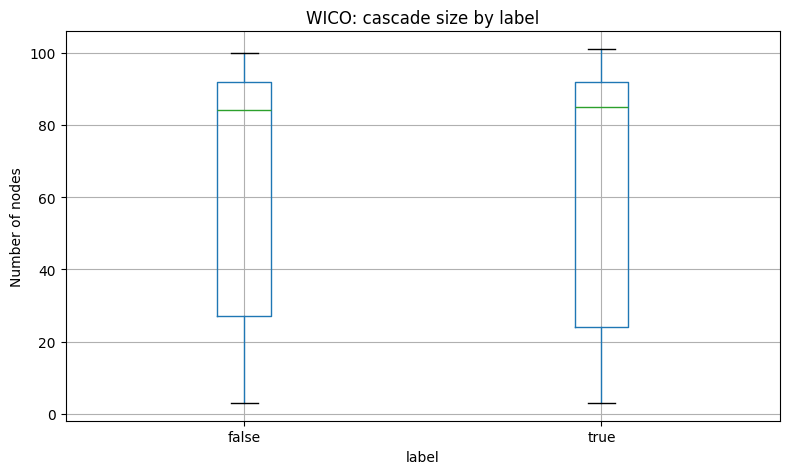

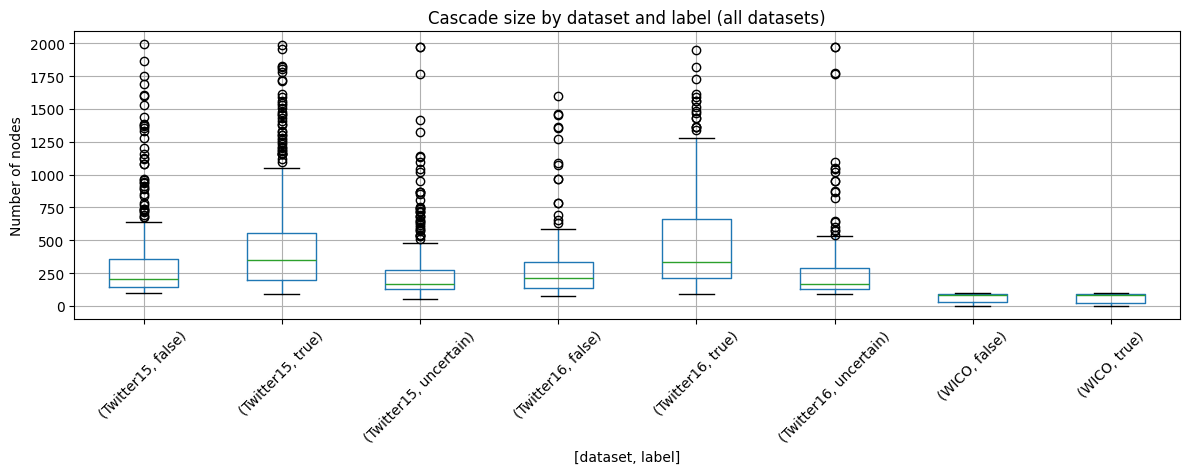

In [14]:
# Quick sanity plot — WICO first, then all datasets
if plt is not None and not tree_summary.empty:
    wico_part = tree_summary[tree_summary['dataset'].eq('WICO')]
    target    = wico_part if not wico_part.empty else tree_summary
    title_pfx = 'WICO' if not wico_part.empty else 'All datasets'

    ax = target.boxplot(column='cascade_size', by='label', rot=0, figsize=(8, 5))
    ax.set_title(f'{title_pfx}: cascade size by label')
    ax.set_ylabel('Number of nodes')
    plt.suptitle('')
    plt.tight_layout()
    out = EVAL_DIR / 'quick_cascade_size_boxplot.png'
    plt.savefig(out, dpi=160)
    print('Saved:', out)

    # Also show all datasets if WICO is available alongside others
    if not wico_part.empty and len(tree_summary['dataset'].unique()) > 1:
        ax2 = tree_summary.boxplot(column='cascade_size', by=['dataset','label'], rot=45, figsize=(12, 5))
        ax2.set_title('Cascade size by dataset and label (all datasets)')
        ax2.set_ylabel('Number of nodes')
        plt.suptitle('')
        plt.tight_layout()
        out2 = EVAL_DIR / 'quick_cascade_size_boxplot_all.png'
        plt.savefig(out2, dpi=160)
        print('Saved:', out2)
    plt.show()
else:
    print('No plot created.')
